# RidgeLFMM

> Ridge solutions to a Latent factor mixed model

Ridge solutions to a Latent factor mixed model as developed by @Caye_2019.

TODO!

In [ ]:
#| default_exp RidgeLFMM

In [ ]:
#| hide
from fastcore.utils import *
from nbdev.showdoc import *
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.linalg import svd, inv
from TracyWidom import TracyWidom
from scipy.stats import f
from numba import njit, jit
from collections import namedtuple

In [ ]:
#| export
class RidgeLFMM:
    "Ridge solutions to a Latent Factor Mixed Model (LFMM)."
    
    def __init__(self, 
                 K: int, # Number of latent factors 
                 lambd: float): # Regularization parameter
        self.U, self.V, self.B = None, None, None
        self.K = K
        self.lambd = lambd

    def __str__(self):
        "Returns a string representation of the RidgeLFMM instance."
        return f"RidgeLFMM model with K={self.K} and lambda={self.lambd}"
    __repr__ = __str__

In order to use the model we have first to initialize it with the number of latent factors $K$. 

In [ ]:
K = 2
lambd = 1e-5
model = RidgeLFMM(K, lambd)

Then, we have to fit the model. That is, ...

$$
\mathbf Y = \mathbf X \mathbf B^T + \mathbf W = \mathbf X \mathbf B^T + \mathbf U \mathbf V^T
$$

In [ ]:
#| hide
def lfmm2(Y, X, K, lambd=1e-5, center=True):
    # Assumes data has been already centered
    n, p = X.shape
    # Singular Value Decomposition (SVD) of X
    Q, sigma, _ = svd(X, overwrite_a=True)
    # Create the diagonal matrix D
    d = np.ones(n)
    d_inv = np.ones(n)
    # R implementation doesn't use square sigma
    # although I think the paper does
    d[:p] = np.sqrt(lambd / (lambd + sigma**2))
    d_inv[:p] = np.sqrt((lambd + sigma**2) / lambd)
    D = np.diag(d)
    Dinv = np.diag(d_inv)
    # SVD of the modified Y (D * Q.T * Y)
    U_svd, S_svd, Vt_svd = svd(np.dot(D, np.dot(Q.T, Y)), full_matrices=False)
    # Get first K components from SVD
    U = np.dot(np.dot(Q, Dinv), U_svd[:, :K]) * S_svd[:K]
    Vt = Vt_svd[:K, :]
    # Ridge regression to compute Bt
    Bt = np.linalg.inv(np.dot(X.T, X) + lambd * np.eye(p)).dot(X.T).dot(Y - np.dot(U, Vt))
    return U, Vt.T, Bt.T

In [ ]:
#|export
@patch
def fit(self:RidgeLFMM,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray): # Environmental matrix (nxP)
    "Fits the LFMM model. "
    n1, L = Y.shape
    n2, P = X.shape
    if n1 != n2: 
        raise ValueError("Dimensions of array don't match")
    Y = Y - np.mean(Y, axis=0)
    X = X - np.mean(X, axis=0)
    self.U, self.V, self.B = lfmm2(Y, X, self.K, self.lambd)


The `fit()` method expects as input an allele matrix $\mathbf Y$ and an environmental matrix $\mathbf X$ with as many rows as individuals. For now, let us simulate them under the ¿generative model?: 

In [ ]:
def generative_model(rng, N, L, P, n_targets):
    X = rng.normal(size=N)
    B = np.zeros(L)
    target_indices = rng.choice(L, n_targets, replace=False)
    B[target_indices] = rng.uniform(-10, 10, size=n_targets)
    U = np.dot(X.reshape(-1, 1), np.array([[-1, 0.5, 1.5]])) + rng.normal(size=(N, 3))
    V = rng.normal(size=(3, L))  # V should have 3 rows to match the columns of U
    Y = np.dot(X.reshape(-1, 1), B.reshape(1, -1)) + np.dot(U, V) + rng.normal(scale=0.5, size=(N, L))
    Y = (Y > 0).astype(int)
    X = np.hstack((X.reshape(-1, 1),  rng.normal(size=(N, P-1))))
    assert X.shape == (N, P)
    assert Y.shape == (N, L)
    return Y, X
rng = np.random.default_rng(1000)
Y, X = generative_model(rng, N=100, L=500, P=10, n_targets=10)

Now, we can fit the model:

In [ ]:
model.fit(Y, X)

And access the solutions: 

In [ ]:
model.B

array([[-2.78448272e-01,  1.41584734e-02,  5.13772490e-02, ...,
        -1.47202536e-04, -1.86642329e-02, -2.08873092e-02],
       [ 2.47111100e-01,  1.43403921e-02,  2.37815104e-02, ...,
        -8.21643055e-03,  5.95489715e-02, -2.60489389e-02],
       [ 2.73904999e-01, -3.82791956e-02,  1.26496721e-02, ...,
         8.67474342e-03,  5.68635936e-02, -2.62721821e-03],
       ...,
       [ 2.69963998e-01, -3.16104750e-03, -1.20699168e-02, ...,
         4.24987609e-02,  2.03429814e-02, -3.71159238e-04],
       [-4.61025280e-02, -2.54862481e-02,  6.31753948e-02, ...,
         9.79880322e-03, -5.75179559e-02,  2.55968959e-02],
       [-3.92402195e-01,  2.47179747e-02, -2.53286475e-02, ...,
        -2.03821485e-02, -3.63830664e-02, -3.65641809e-02]])

As you may notice, the choice of $K$ has to be done. This is typically done using with screeplot. We are not re-inventing the wheel, as they are many libraries available: 

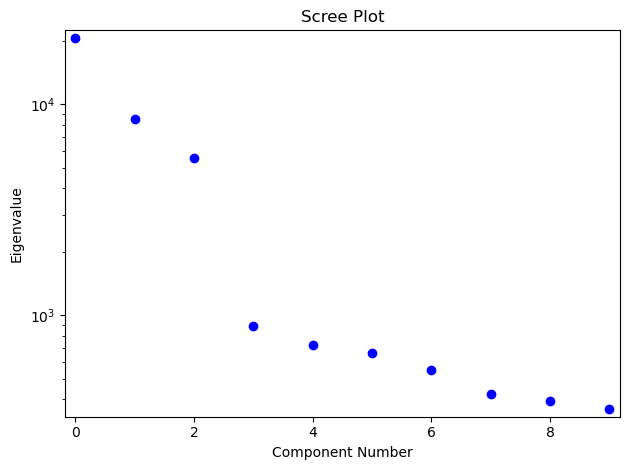

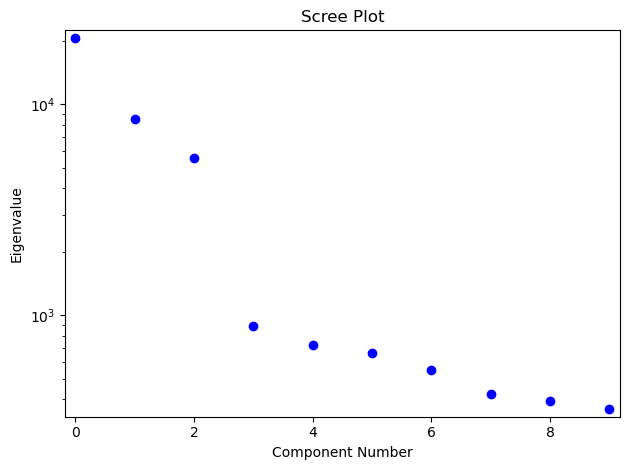

In [ ]:
sm.PCA(Y, ncomp=10).plot_scree()

In [ ]:
# We can test against the LFMM2 library: 
import rpy2
from rpy2.robjects.packages import importr
from rpy2.robjects import numpy2ri
from rpy2.robjects import default_converter

# import R's "base" package
LEA = importr('LEA')

# Create a converter that starts with rpy2's default converter
# to which the numpy conversion rules are added.
np_cv_rules = default_converter + numpy2ri.converter

with np_cv_rules.context():
    # Anything here and until the `with` block is exited
    # will use our numpy converter whenever objects are
    # passed to R or are returned by R while calling
    # rpy2.robjects functions.
    rng = np.random.default_rng()
    N = rng.integers(low=1, high=300)
    L = rng.integers(low=1, high=1000)
    P = rng.integers(low=1, high=min(50, N-1))
    n_targets = rng.integers(low=0, high=L)
    # Simulate data
    Y, X = generative_model(rng, N=N, L=L, P=P, n_targets=n_targets)
    # Simulate hyperparameters
    Ks = rng.integers(low=1, high=min(2, min(L, P)), size = 5)
    lambdas = rng.uniform(low=1e-6, high=1e3, size = 5)
    lambd = 1e-5
    model = RidgeLFMM(K, lambd)
    print(f"Y shape is {Y.shape}")
    print(f"X shape is {X.shape}")
    for K, lambd in zip(Ks, lambdas):
        model = RidgeLFMM(K, lambd)
        model.fit(Y, X)
        r_model = LEA.lfmm2(Y, X, model.K, model.lambd, True)
        # Until we sold the issue with the squared singular values, we will not
        # test this directly let this
        print(f"K={K}, lambda={lambd}")
        print(np.linalg.norm(np.asarray(r_model.slots["B"]) - model.B))
        print(np.linalg.norm(np.asarray(r_model.slots["U"]) - model.U))
        print(np.linalg.norm(np.asarray(r_model.slots["V"]) - model.V))

Y shape is (237, 731)
X shape is (237, 29)
K=1, lambda=937.848127563516
0.023423385962846013
0.3572737386230281
0.012324407299087946
K=1, lambda=920.2919354912203
0.024180403722115804
0.36380182114614273
0.012545129777144002
K=1, lambda=644.6696645504057
0.04329626140057386
0.5103869466492983
0.017461221269808307
K=1, lambda=944.1284655752506
0.02316125584255261
0.35499515914879287
0.012247329390169063
K=1, lambda=451.8179863012732
0.07480425915486347
0.7116817316785023
0.024090173284407206


## Tracy-Widom test


In [ ]:
#| hide
@njit
def _TracyWidom_statistic(
    eigenvalues: np.ndarray, # Array of eigenvalues
    ) -> np.ndarray: # Array of the Tracy-Widom statistics.
    L1 = np.cumsum(np.flip(eigenvalues))
    L1 = np.flip(L1)  # Reverse the result
    L2 = np.cumsum(np.flip(eigenvalues ** 2))
    L2 = np.flip(L2)
    N = np.arange(len(eigenvalues), 0, -1)
    S2 = (N ** 2 * L2) / (L1 ** 2)
    v = N * (N + 2) / (S2 - N)
    L = N * eigenvalues / L1
    v_st = np.where(v - 1 > 0, v - 1, np.nan)
    v_st = np.sqrt(v_st)
    N_st = np.sqrt(N)
    mu = ((v_st + N_st) ** 2) / v
    sigma = (v_st + N_st) / v * (1 / v_st + 1 / N_st) ** (1 / 3)
    twstat = (L - mu) / sigma
    return twstat

In [ ]:
#| export
TracyWidomTest = namedtuple("TracyWidomTest", "statistics pvalues")
def TracyWidom_from_eigenvalues(
        eigenvalues: np.ndarray # Array of eigenvalues
        ) -> TracyWidomTest:
    twstat = _TracyWidom_statistic(eigenvalues)
    pvalues = 1- TracyWidom(beta=1).cdf(twstat)
    return TracyWidomTest(twstat, pvalues)

In [ ]:
TracyWidom_from_eigenvalues(np.array([5, 3, 1, 0]))

TracyWidomTest(statistics=array([-0.82427304, -0.60185543, -0.55524569,         nan]), pvalues=array([0.36404483, 0.30250909, 0.29035233,        nan]))

In [ ]:
#| hide
# From AssocTest R package
test_cases = [
    (np.array([5, 3, 1, 0]), np.array([-0.8242730, -0.6018554, -0.5552457, np.nan])),
    (np.array([35, 12, 10, 1]), np.array([-0.507243, -1.350166, -0.632759, np.nan])),
    (np.array([35, 12, 10, 1, 0]), np.array([-0.4632767, -1.2003935, -0.4407791, -0.5552457,np.nan]))
]

for eigens, expected in test_cases:
    assert np.nansum(np.abs(TracyWidom_from_eigenvalues(eigens).statistics - expected)) < 1e-5

In [ ]:
#| hide
def TracyWidom_from_matrix(
        mat: np.ndarray # Genotype matrix
        ) -> TracyWidomTest:
    eigenvalues = sm.PCA(mat).eigenvals
    return TracyWidom_from_eigenvalues(eigenvalues)

You can find the number of significant eigenvalues to choose as latent factors: 

In [ ]:
#| export
def search_latent_factors_with_TracyWidom(
        mat: np.ndarray, # Genotype matrix
        thresholds: np.ndarray # Array of significance levels
        ) -> int: # Number of significant eigenvalues
    n = len(thresholds)
    res = np.zeros(n)
    tw = TracyWidom_from_matrix(mat)
    for i in range(n):
        indices = np.where(tw.pvalues > thresholds[i])[0]
        if len(indices) > 0:
            res[i] = indices[0] - 1
    return res

In [ ]:
search_latent_factors_with_TracyWidom(Y, np.array([1e-1, 1e-3, 1e-5]))

array([21., 18., 16.])

## GEA candidates

We can use F-test based on the LFMM model to find GEA candidates:

In [ ]:
#|export
@patch
def FTest(self:RidgeLFMM,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray, # Environmental matrix (nxP)
        genomic_control: bool=True, # whether to use genomic control
         ) -> np.ndarray: # Array of p-values (L) 
    "Re-fit the coefficient of the LFMM model and make an F-test."
    Y = Y - np.mean(Y, axis=0)
    X = X - np.mean(X, axis=0)
    n, d = X.shape
    U = np.hstack([np.ones((n, 1)), model.U])
    U_inv_Y = np.linalg.lstsq(U, Y, rcond=None)[0]
    res_Y = Y - U @ U_inv_Y
    res_X = X - U @ np.linalg.lstsq(U, X, rcond=None)[0]
    res_X = np.hstack([np.ones((n, 1)), res_X])
    fitted = res_X @ np.linalg.lstsq(res_X, res_Y, rcond=None)[0]
    mss = np.sum(np.abs(fitted) ** 2, axis=0)
    resvar = np.sum(np.abs(res_Y - fitted) ** 2, axis=0) / (n - d - 1)
    resvar = np.maximum(resvar, 1e-10)  # Numerical stability
    Fscores = mss / (d * resvar)
    dist = f(d, n - d - 1)   
    if genomic_control:
        gif = np.median(Fscores) / dist.ppf(0.5)
        Fscores /= gif
    pvalues = 1 - dist.cdf(Fscores)
    return np.ravel(pvalues)


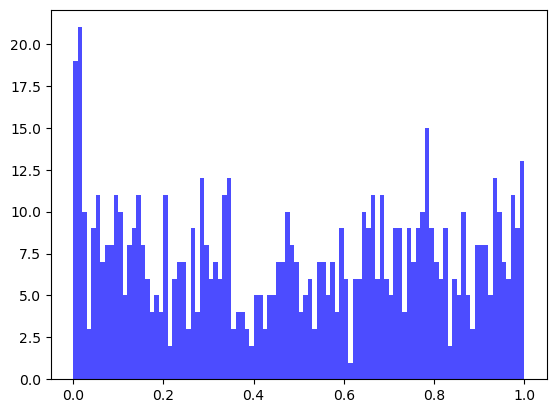

In [ ]:
fig, ax = plt.subplots()
pvalues = model.FTest(Y, X)
ax.hist(pvalues, 100, color='blue', alpha=0.7)
plt.show()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()